# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [19]:
# Your code goes here
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [11]:
# Unzip Nasdaq
with zipfile.ZipFile('/content/data_nasdaq_csv.zip') as z:
    z.extractall('/content/nasdaq_data')

# Unzip Vietnam
with zipfile.ZipFile('/content/data-vn-20230228.zip') as z:
    z.extractall('/content/vn_data')

print("Done unzipping")

Done unzipping


Nasdaq folder: /content/nasdaq_data/csv
Example files: ['PPBI.csv', 'SKYS.csv', 'WSBF.csv', 'IPCC.csv', 'PYS.csv']
['Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted Close']
       Open      High       Low     Close     Volume  Adjusted Close
0  0.128348  0.128906  0.128348  0.128348  469033600        0.099874
1  0.122210  0.122210  0.121652  0.121652  175884800        0.094663
2  0.113281  0.113281  0.112723  0.112723  105728000        0.087715
3  0.115513  0.116071  0.115513  0.115513   86441600        0.089886
4  0.118862  0.119420  0.118862  0.118862   73449600        0.092492


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 7.9035e-06 - val_loss: 1.4996e-05
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5.6561e-07 - val_loss: 1.5319e-05
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5.8093e-07 - val_loss: 1.2540e-05
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 6.7379e-07 - val_loss: 1.3069e-05
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 5.5404e-07 - val_loss: 1.8133e-05
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5.3652e-07 - val_loss: 1.0551e-05
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 4.7536e-07 - val_loss: 1.3503e-05
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 4.5731e-07 - val_loss: 1.5024e-05
Epoch 9/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5.1936e-07 - val_loss: 9.7665e-06
Epoch 10/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4.4189e-07 - val_loss: 1.1012e-05
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Task 1.1 R

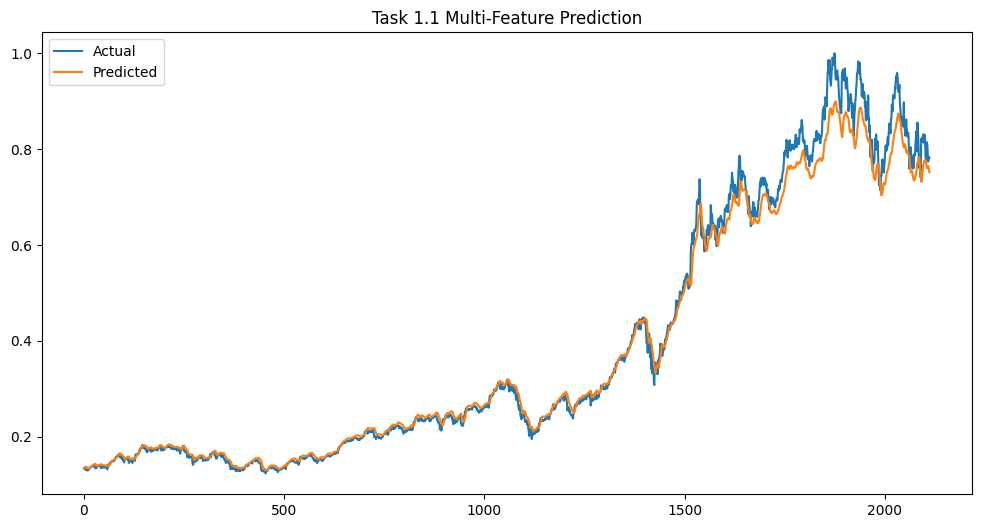

In [13]:
# Task 1.1: Multi-Feature Prediction
# 1. Find Nasdaq CSV folder
for root, dirs, files in os.walk('/content/nasdaq_data'):

    # Ignore __MACOSX folders
    if '__MACOSX' in root:
        continue

    csv_files = [
        f for f in files
        if f.endswith('.csv') and not f.startswith('._')
    ]

    if csv_files:
        nasdaq_folder = root

        print("Nasdaq folder:", nasdaq_folder)
        print("Example files:", csv_files[:5])

        break

# Load AAPL
df = pd.read_csv(os.path.join(nasdaq_folder, 'AAPL.csv'))

# Multi-feature input
features = ['Open', 'High', 'Low', 'Close', 'Volume']

if 'Adj Close' in df.columns:
    features.append('Adj Close')
elif 'Adjusted Close' in df.columns:
    features.append('Adjusted Close')

df = df[features].dropna()

# Scale
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

close_index = features.index('Close')

print(features)
print(df.head())

# Create sequences
window_size = 30

X = []
y = []

for i in range(window_size, len(scaled) - 1):
    X.append(scaled[i - window_size:i])
    y.append(scaled[i + 1][close_index])  # Close price

X = np.array(X)
y = np.array(y)

# Split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Build model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Task 1.1 Results")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title('Task 1.1 Multi-Feature Prediction')

plt.legend()
plt.show()

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 4.9045e-06 - val_loss: 2.9098e-05
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1.1658e-06 - val_loss: 2.8017e-05
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.2897e-06 - val_loss: 2.8844e-05
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.4087e-06 - val_loss: 2.7128e-05
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1.1688e-06 - val_loss: 2.9030e-05
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1.1462e-06 - val_loss: 3.6680e-05
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.1406e-06 - val_loss: 3.1471e-05
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 1.1484e-06 - val_loss: 2.5615e-05
Epoch 9/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 1.0560e-06 - val_loss: 2.9770e-05
Epoch 10/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.0060e-06 - val_loss: 2.6880e-05
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Task 1.2 Results - 7t

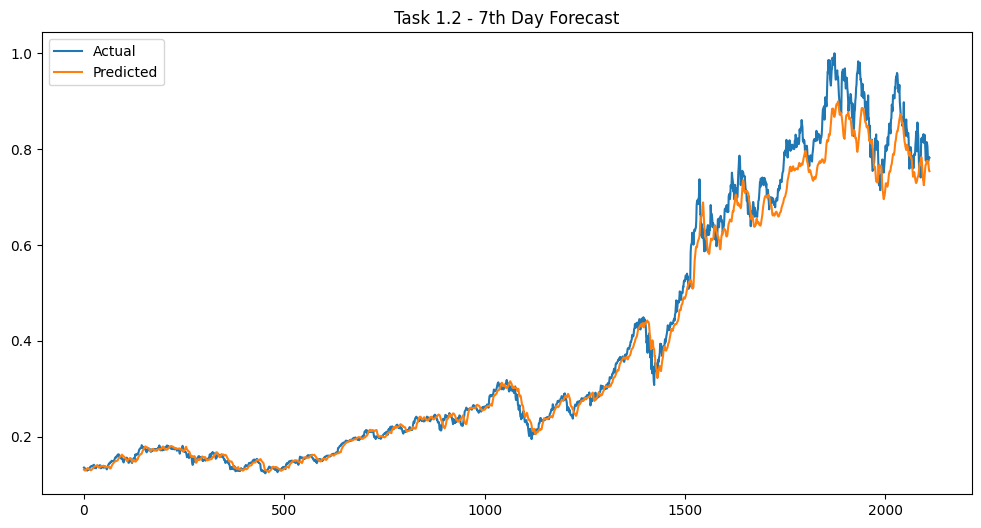

In [14]:
# Task 1.2 - kth-Day Forecast

window_size = 30
k = 7

X = []
y = []

# change len(scaled) - 1 to len(scaled) - k
for i in range(window_size, len(scaled) - k):

    X.append(scaled[i-window_size:i])

    # kth-day future Close price
    y.append(scaled[i + k][close_index])

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Task 1.2 Results - {k}th Day Forecast")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title(f'Task 1.2 - {k}th Day Forecast')

plt.legend()
plt.show()

X shape: (10553, 30, 6)
y shape: (10553, 7)
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.7063e-05 - val_loss: 2.7939e-05
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.1111e-06 - val_loss: 2.6515e-05
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1.0208e-06 - val_loss: 2.3569e-05
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9.7222e-07 - val_loss: 2.6041e-05
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 9.7407e-07 - val_loss: 2.5327e-05
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 8.7099e-07 - val_loss: 2.2912e-05
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 8.5002e-07 - val_loss: 2.6445e-05
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 7.9748e-07 - val_loss: 2.2506e-05
Epoch 9/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 7.9350e-07 - val_loss: 2.4335e-05
Epoch 10/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 8.2250e-07 - val_loss: 1.9524e-05
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Task 1.3 Results - Ne

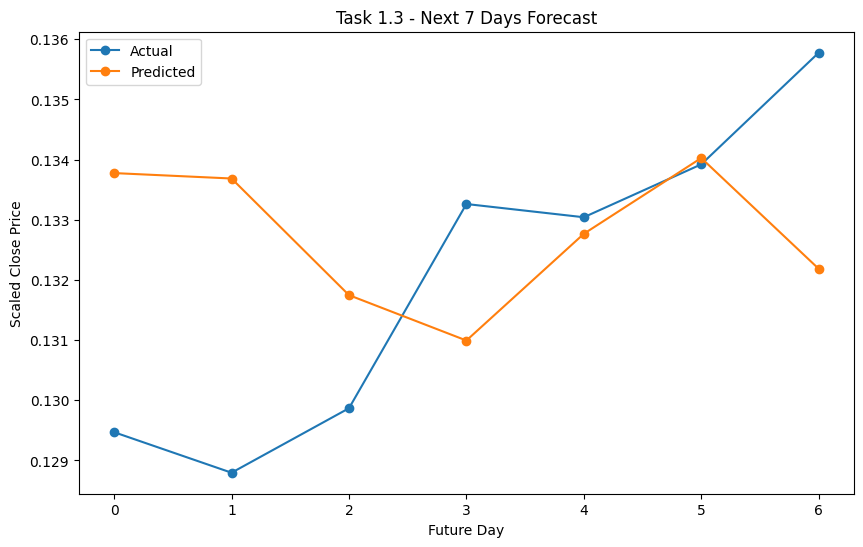

In [15]:
# Task 1.3 - k Days Forecast

window_size = 30
k = 7   # predict next 7 consecutive days

X = []
y = []

for i in range(window_size, len(scaled) - k):

    # past 30 days, all features
    X.append(scaled[i-window_size:i])

    # next k consecutive Close prices
    y.append(scaled[i+1:i+k+1, close_index])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(k)   # output k future days
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Task 1.3 Results - Next {k} Days Forecast")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot first prediction example
plt.figure(figsize=(10,6))

plt.plot(y_test[0], marker='o', label='Actual')
plt.plot(predictions[0], marker='o', label='Predicted')

plt.title(f'Task 1.3 - Next {k} Days Forecast')

plt.xlabel('Future Day')
plt.ylabel('Scaled Close Price')

plt.legend()
plt.show()

Vietnam folder: /content/vn_data/stock-historical-data
Example files: ['L63-UpcomIndex-History.csv', 'PXI-UpcomIndex-History.csv', 'IJC-VNINDEX-History.csv', 'XPH-UpcomIndex-History.csv', 'HCB-UpcomIndex-History.csv']
   Unnamed: 0    Open    High     Low   Close  Volume TradingDate
0           0  8867.0  8867.0  8867.0  8900.0    1000  2016-10-06
1           1  8867.0  8867.0  8867.0  8900.0       0  2016-10-07
2           2  8867.0  8867.0  8867.0  8900.0       0  2016-10-10
3           3  8867.0  8867.0  8867.0  8900.0       0  2016-10-11
4           4  8867.0  8867.0  8867.0  8900.0       0  2016-10-12
Index(['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', 'TradingDate'], dtype='object')
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0096 - val_loss: 0.0019
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0032 - val_loss: 0.0014
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0024 - val_loss: 0.0013
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0022 - val_loss: 0.0013
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0021 - val_loss: 0.0013
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0020 - val_loss: 0.0013
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0019 - val_loss: 0.0013
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Task 2.1 Results
MAE: 0.02375129001451384
RMSE: 0.03863071696892885


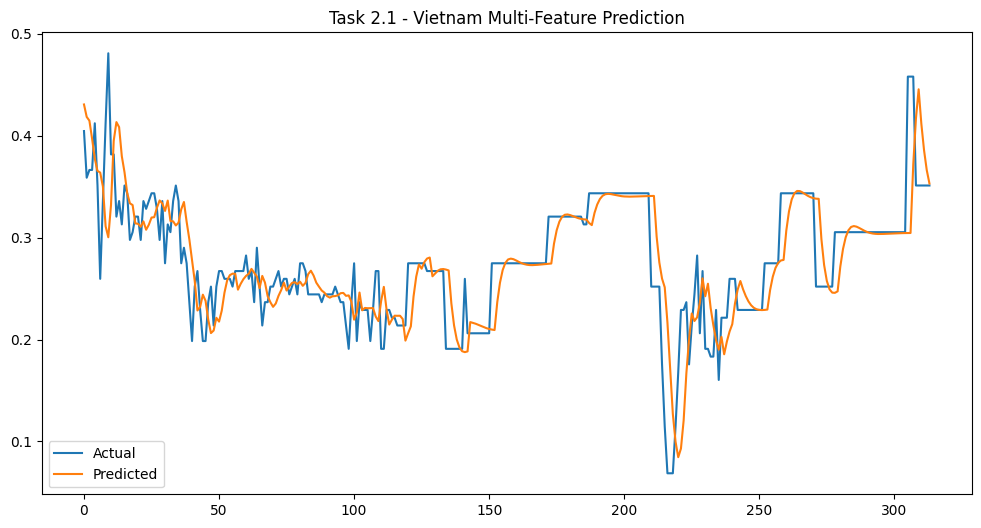

In [16]:
# Task 2.1 - Vietnam Multi-Feature Extension

# Find Vietnam stock csv files
for root, dirs, files in os.walk('/content/vn_data/stock-historical-data'):
    csv_files = [f for f in files if f.endswith('.csv')]
    if csv_files:
        vn_folder = root
        print("Vietnam folder:", vn_folder)
        print("Example files:", csv_files[:5])
        break

# Load one Vietnam stock
df = pd.read_csv(os.path.join(vn_folder, csv_files[0]))

print(df.head())
print(df.columns)

# Vietnam multi-feature input
features = ['Open', 'High', 'Low', 'Close', 'Volume']

df = df[features].dropna()

# Scale data
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

close_index = features.index('Close')

# Create sequences
window_size = 30

X = []
y = []

for i in range(window_size, len(scaled) - 1):

    X.append(scaled[i-window_size:i])

    # next-day Close price
    y.append(scaled[i + 1][close_index])

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Task 2.1 Results")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title('Task 2.1 - Vietnam Multi-Feature Prediction')

plt.legend()
plt.show()

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0378 - val_loss: 0.0023
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0102 - val_loss: 0.0023
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0095 - val_loss: 0.0023
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0091 - val_loss: 0.0023
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0088 - val_loss: 0.0024
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0084 - val_loss: 0.0023
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0079 - val_loss: 0.0033
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0077 - val_loss: 0.0025
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0078 - val_loss: 0.0024
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0073 - val_loss: 0.0024
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Task 2.2 Results - 7th Day Forecast
MAE: 0.039005214230733935
RMSE: 0.055988497053656834


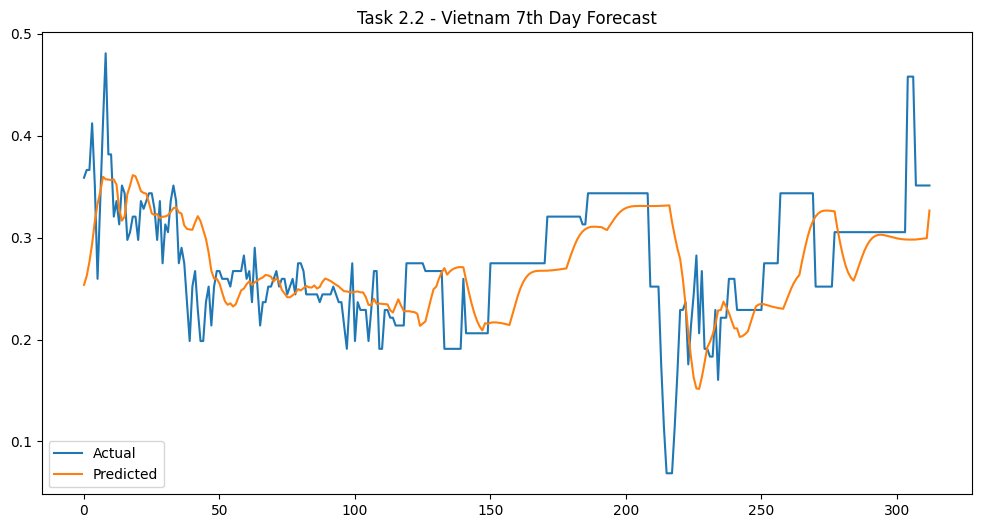

In [17]:
# Task 2.2 - Vietnam kth-day forecast

window_size = 30
k = 7

X = []
y = []

for i in range(window_size, len(scaled) - k):

    X.append(scaled[i-window_size:i])

    # kth-day future Close price
    y.append(scaled[i + k][close_index])

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Task 2.2 Results - {k}th Day Forecast")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title(f'Task 2.2 - Vietnam {k}th Day Forecast')

plt.legend()
plt.show()

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0340 - val_loss: 0.0029
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0075 - val_loss: 0.0017
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0070 - val_loss: 0.0017
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0064 - val_loss: 0.0017
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0062 - val_loss: 0.0020
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0061 - val_loss: 0.0019
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0058 - val_loss: 0.0016
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0054 - val_loss: 0.0018
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0052 - val_loss: 0.0017
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0050 - val_loss: 0.0018
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Task 2.3 Results - Next 7 Days Forecast
MAE: 0.03473272627927555
RMSE: 0.05219003050552946


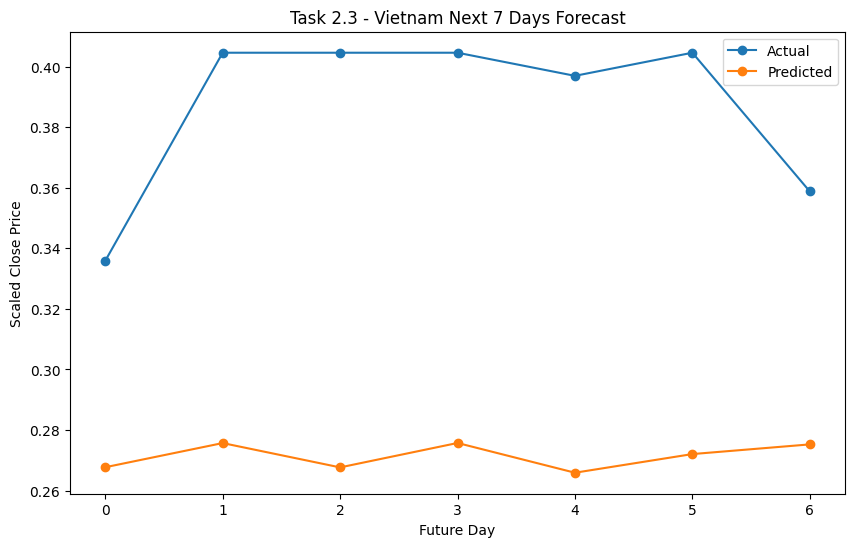

In [18]:
# Task 2.3 - Vietnam k Days Forecast

window_size = 30
k = 7

X = []
y = []

for i in range(window_size, len(scaled) - k):

    X.append(scaled[i-window_size:i])

    # next k consecutive Close prices
    y.append(scaled[i+1:i+k+1, close_index])

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),

    # output k future days
    Dense(k)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Task 2.3 Results - Next {k} Days Forecast")
print("MAE:", mae)
print("RMSE:", rmse)

# Plot first prediction example
plt.figure(figsize=(10,6))

plt.plot(y_test[0], marker='o', label='Actual')
plt.plot(predictions[0], marker='o', label='Predicted')

plt.title(f'Task 2.3 - Vietnam Next {k} Days Forecast')

plt.xlabel('Future Day')
plt.ylabel('Scaled Close Price')

plt.legend()
plt.show()

In [23]:
# Task 3.1 - Buying Signal Identification
window_size = 30
future_window = 7
buy_threshold = 0.05 # 5% increase

close_prices = df['Close'].values

X = []
y = []

for i in range(window_size, len(scaled) - future_window):

    current_close = close_prices[i]

    future_close = close_prices[i + future_window]

    future_return = (
        future_close - current_close
    ) / current_close

    X.append(scaled[i-window_size:i])

    # BUY = 1
    # NOT BUY = 0
    if future_return >= buy_threshold:
        y.append(1)
    else:
        y.append(0)

X = np.array(X)
y = np.array(y)

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Classification model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict probabilities
buy_probabilities = model.predict(X_test)

# Convert probabilities to 0 or 1
buy_predictions = (
    buy_probabilities >= 0.5
).astype(int)

# Metrics
accuracy = accuracy_score(
    y_test,
    buy_predictions
)

precision = precision_score(
    y_test,
    buy_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    buy_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    buy_predictions,
    zero_division=0
)

print("Task 3.1 Results")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.7696 - loss: 0.5460 - val_accuracy: 0.7440 - val_loss: 0.5993
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8230 - loss: 0.4624 - val_accuracy: 0.7440 - val_loss: 0.5728
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8230 - loss: 0.4625 - val_accuracy: 0.7440 - val_loss: 0.5945
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8230 - loss: 0.4629 - val_accuracy: 0.7440 - val_loss: 0.6026
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8230 - loss: 0.4672 - val_accuracy: 0.7440 - val_loss: 0.5850
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8230 - loss: 0.4629 - val_accuracy: 0.7440 - val_loss: 0.5807
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8230 - loss: 0.4627 - val_accuracy: 0.7440 - val_loss: 0.5748
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8230 - loss: 0.4616 - val_accuracy: 0.7440 - val_loss: 0.

In [24]:
# Task 3.2 - Selling Signal Identification

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

window_size = 30
future_window = 7

sell_threshold = -0.05   # 5% decrease

close_prices = df['Close'].values

X = []
y = []

for i in range(window_size, len(scaled) - future_window):

    current_close = close_prices[i]

    future_close = close_prices[i + future_window]

    future_return = (
        future_close - current_close
    ) / current_close

    X.append(scaled[i-window_size:i])

    # SELL = 1
    # NOT SELL = 0
    if future_return <= sell_threshold:
        y.append(1)
    else:
        y.append(0)

X = np.array(X)
y = np.array(y)

print("SELL signals:", np.sum(y))
print("NOT SELL signals:", len(y) - np.sum(y))

# Chronological split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Classification model
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Predict probabilities
sell_probabilities = model.predict(X_test)

# Convert probabilities to 0 or 1
sell_predictions = (
    sell_probabilities >= 0.5
).astype(int)

# Metrics
accuracy = accuracy_score(
    y_test,
    sell_predictions
)

precision = precision_score(
    y_test,
    sell_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    sell_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    sell_predictions,
    zero_division=0
)

print("Task 3.2 Results")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

SELL signals: 282
NOT SELL signals: 1280
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8203 - loss: 0.5214 - val_accuracy: 0.7760 - val_loss: 0.5411
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8381 - loss: 0.4473 - val_accuracy: 0.7760 - val_loss: 0.5441
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8381 - loss: 0.4391 - val_accuracy: 0.7760 - val_loss: 0.5451
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8381 - loss: 0.4342 - val_accuracy: 0.7760 - val_loss: 0.5545
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8381 - loss: 0.4281 - val_accuracy: 0.7760 - val_loss: 0.5428
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8381 - loss: 0.4256 - val_accuracy: 0.7760 - val_loss: 0.5489
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8390 - loss: 0.4281 - val_accuracy: 0.7760 - val_loss: 0.5762
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8434 - loss: 0.4236 - val_accuracy: 0.7760 - val_loss: 0.